# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import kagglehub
# from keras.preprocessing.image import ImageDataGenerator
from keras.utils import image_dataset_from_directory

import tensorflow as tf
from keras.models import Sequential
from keras import layers
from keras.layers import Dense,Conv2D, GlobalAveragePooling2D
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
# pre-traind model

from keras.applications import EfficientNetV2B3, DenseNet121

# Data Loading and Data Engineering

In [3]:
path = kagglehub.dataset_download("pacificrm/skindiseasedataset")
print(path)

100%|██████████| 1.36G/1.36G [01:35<00:00, 15.4MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6


In [4]:
# Extracting paths by keep driling
os.listdir(path)
path1 = os.path.join(path, 'SkinDisease')
print(path1)

os.listdir(path1)
path2 = os.path.join(path1, 'SkinDisease')
os.listdir(path2)
print(path2)

print(os.listdir(path2))

train_path = os.path.join(path2, 'train')
test_path = os.path.join(path2, 'test')

/root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6/SkinDisease
/root/.cache/kagglehub/datasets/pacificrm/skindiseasedataset/versions/6/SkinDisease/SkinDisease
['train', 'test']


In [13]:
# using modern API image_dataset_from_directory

train_datasets = image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42,
    label_mode='categorical'
)
test_datasets = image_dataset_from_directory(
    test_path,
    image_size=(224, 224), # for efficent net model
    batch_size=32,
    # shuffle=True,  not
    seed=42,
    label_mode='categorical'
)

Found 13898 files belonging to 22 classes.
Found 1546 files belonging to 22 classes.


In [6]:
train_datasets

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 22), dtype=tf.float32, name=None))>

In [14]:
# save the class names
class_names = train_datasets.class_names
print(class_names)

['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']


In [15]:
# Normaliza the data value
train_ds = train_datasets.map(lambda x, y: (x/255.0, y))
test_ds = test_datasets.map(lambda x, y: (x/255.0, y))


# Visualizaing the images

In [58]:
def visualize_10_images_foraclass(train_ds, target_cls):
    num_images = 5
    # Extract images with the same class
    for image_batch, label_batch in train_ds:
        images = []
        cls_ids = tf.argmax(label_batch, axis=1)
        for image, cls in zip(image_batch, cls_ids):
            if cls == target_cls:
                images.append(image)
                if len(images) == num_images:
                    break

        if len(images) == num_images:
            break
    # Visualiza the images
    plt.figure(figsize=(20, 10))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i])
        label = class_names[target_cls]
        plt.title(label)
        plt.axis('off')


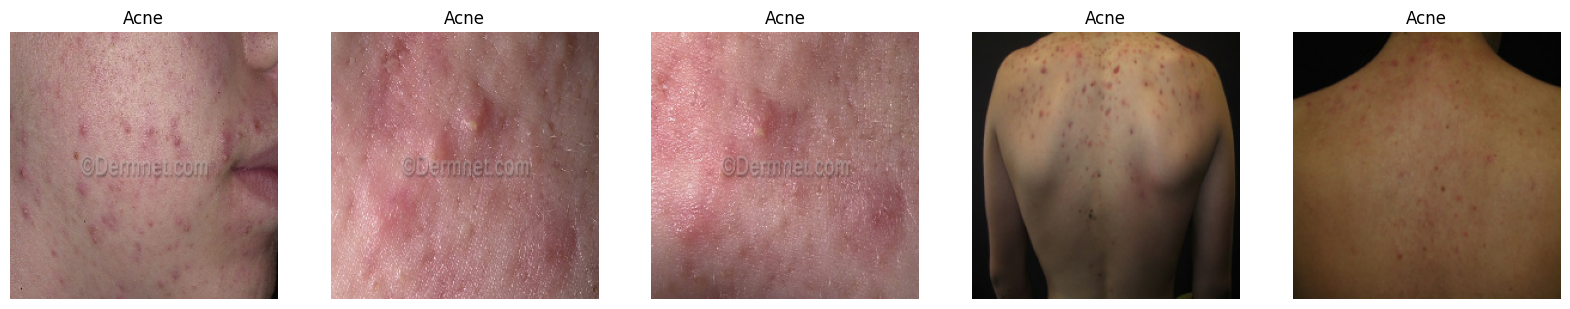

In [59]:
visualize_10_images_foraclass(train_ds, 0)

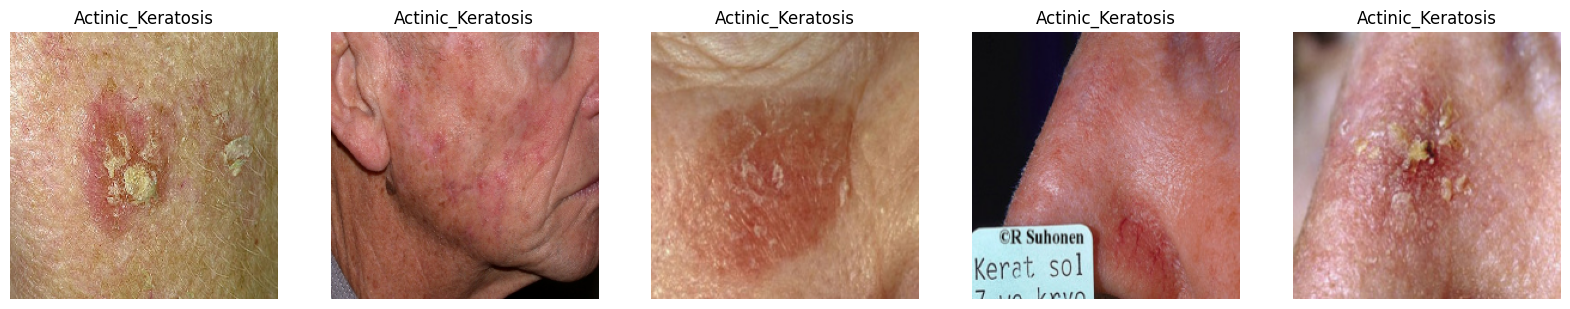

In [60]:
visualize_10_images_foraclass(train_ds, 1)

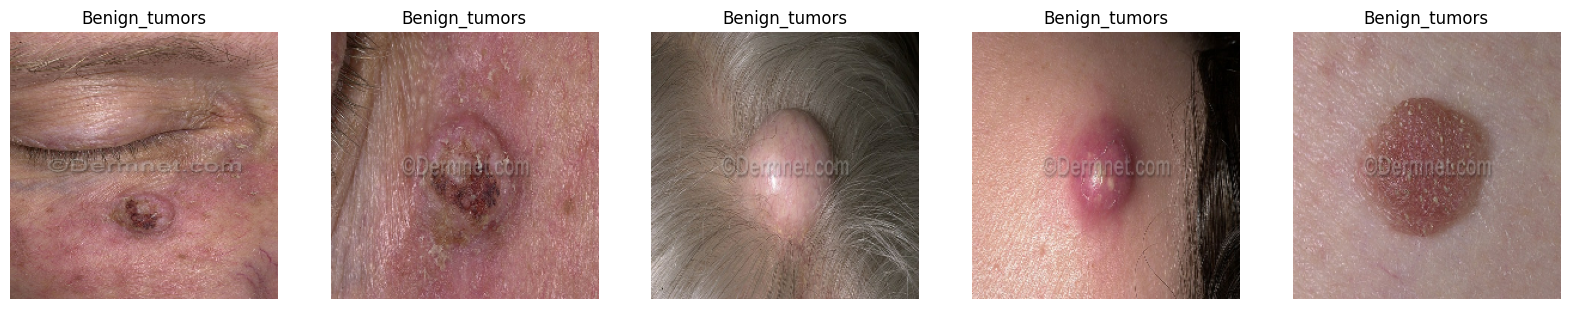

In [61]:
visualize_10_images_foraclass(train_ds, 2)

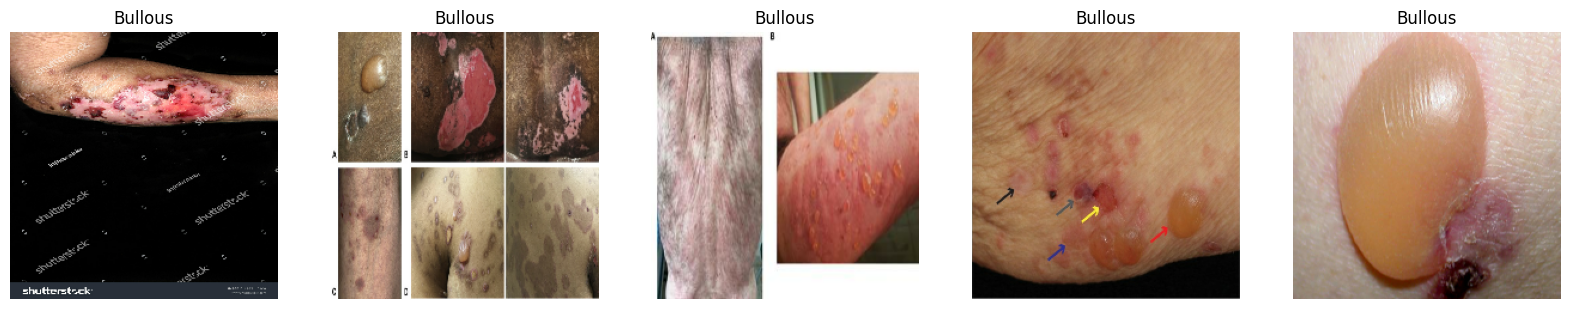

In [62]:
visualize_10_images_foraclass(train_ds, 3)

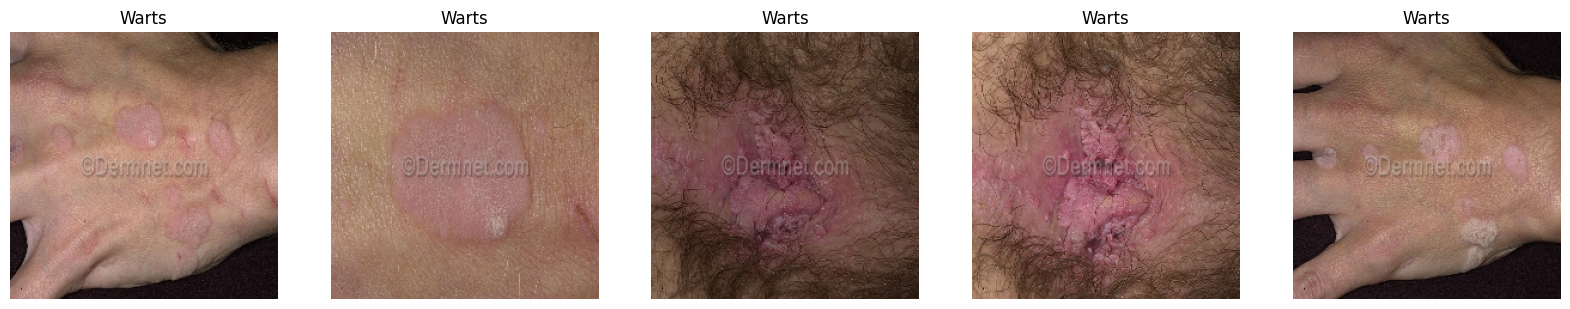

In [63]:
visualize_10_images_foraclass(train_ds, 21)

# Build CNN custom model

In [ ]:
# skin_cnn_model = Sequential([

# ])

# Load the Pre-Trained Model

In [8]:
base_model = DenseNet121(weights='imagenet', include_top=False,)
base_model.summary()


Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, None,      │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,408 │ zero_padding2d[0… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, None,      │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, None,      │          0 │ conv2_block1_0_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, None,      │          0 │ pool1[0][0],      │
│ (Concatenate)       │ None, 96)         │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, None,      │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, None,      │          0 │ conv2_block2_0_b… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, None,      │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 6,953,856 (26.53 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [10]:
early_stopper = EarlyStopping(patience=3,
                              monitor='val_loss',
                              restore_best_weights=True,
                              verbose=1)
lr_reducer = ReduceLROnPlateau(monitor='val_loss',
                               patience=3,
                               factor=0.5,
                               restore_best_weights=True,
                               verbose=1
                               )

In [12]:
train_ds = train_ds.shuffle(buffer_size=1000)

In [17]:

from keras import layers, models

IMG_SIZE = 224
NUM_CLASSES = 22

base_model = tf.keras.applications.DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model first
base_model.trainable = False

# Custom head
x = base_model.output
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# fit the model
history = model.fit(
    train_ds,
    batch_size=64,
    epochs=10,
    validation_data=test_ds,
    callbacks=[early_stopper, lr_reducer],
    verbose=1
)


Epoch 1/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 119s 214ms/step - accuracy: 0.3754 - loss: 2.0863 - val_accuracy: 0.5026 - val_loss: 1.6897 - learning_rate: 0.0010
Epoch 2/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 59s 135ms/step - accuracy: 0.4773 - loss: 1.7023 - val_accuracy: 0.5272 - val_loss: 1.5402 - learning_rate: 0.0010
Epoch 3/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 83s 137ms/step - accuracy: 0.5198 - loss: 1.5491 - val_accuracy: 0.5485 - val_loss: 1.4689 - learning_rate: 0.0010
Epoch 4/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 62s 142ms/step - accuracy: 0.5533 - loss: 1.4365 - val_accuracy: 0.5666 - val_loss: 1.4172 - learning_rate: 0.0010
Epoch 5/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 78s 134ms/step - accuracy: 0.5723 - loss: 1.3653 - val_accuracy: 0.5802 - val_loss: 1.4039 - learning_rate: 0.0010
Epoch 6/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 61s 140ms/step - accuracy: 0.6001 - loss: 1.2815 - val_accuracy: 0.5809 - val_loss: 1.3794 - learning_rate: 0.0010
Epoch 7/10
435/435 ━━━━━━━━━━━━━━━━━━━━ 85s 147ms/step - accuracy: 0.

In [18]:
history2 = model.fit(
    train_ds,
    batch_size=64,
    epochs=5,
    validation_data=test_ds,
    callbacks=[early_stopper, lr_reducer],
    verbose=1
)


Epoch 1/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 62s 143ms/step - accuracy: 0.6654 - loss: 1.0321 - val_accuracy: 0.6028 - val_loss: 1.3343 - learning_rate: 0.0010
Epoch 2/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 60s 139ms/step - accuracy: 0.6819 - loss: 0.9839 - val_accuracy: 0.6093 - val_loss: 1.3427 - learning_rate: 0.0010
Epoch 3/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 75s 171ms/step - accuracy: 0.6982 - loss: 0.9452 - val_accuracy: 0.6125 - val_loss: 1.3312 - learning_rate: 0.0010
Epoch 4/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 69s 159ms/step - accuracy: 0.7010 - loss: 0.9136 - val_accuracy: 0.6190 - val_loss: 1.3332 - learning_rate: 0.0010
Epoch 5/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 60s 137ms/step - accuracy: 0.7143 - loss: 0.8808 - val_accuracy: 0.6100 - val_loss: 1.3168 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


In [19]:
history3 = model.fit(
    train_ds,
    batch_size=64,
    epochs=5,
    validation_data=test_ds,
    callbacks=[early_stopper, lr_reducer],
    verbose=1
)

Epoch 1/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 62s 143ms/step - accuracy: 0.7273 - loss: 0.8365 - val_accuracy: 0.6080 - val_loss: 1.3388 - learning_rate: 0.0010
Epoch 2/5
435/435 ━━━━━━━━━━━━━━━━━━━━ 58s 134ms/step - accuracy: 0.7246 - loss: 0.8295 - val_accuracy: 0.6203 - val_loss: 1.3429 - learning_rate: 0.0010
Epoch 3/5
434/435 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7417 - loss: 0.7970
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
435/435 ━━━━━━━━━━━━━━━━━━━━ 91s 154ms/step - accuracy: 0.7413 - loss: 0.7914 - val_accuracy: 0.6106 - val_loss: 1.3664 - learning_rate: 0.0010
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [21]:
model.save("disease_detector_model.keras")

In [23]:
from google.colab import files
# Download the model
files.download('disease_detector_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


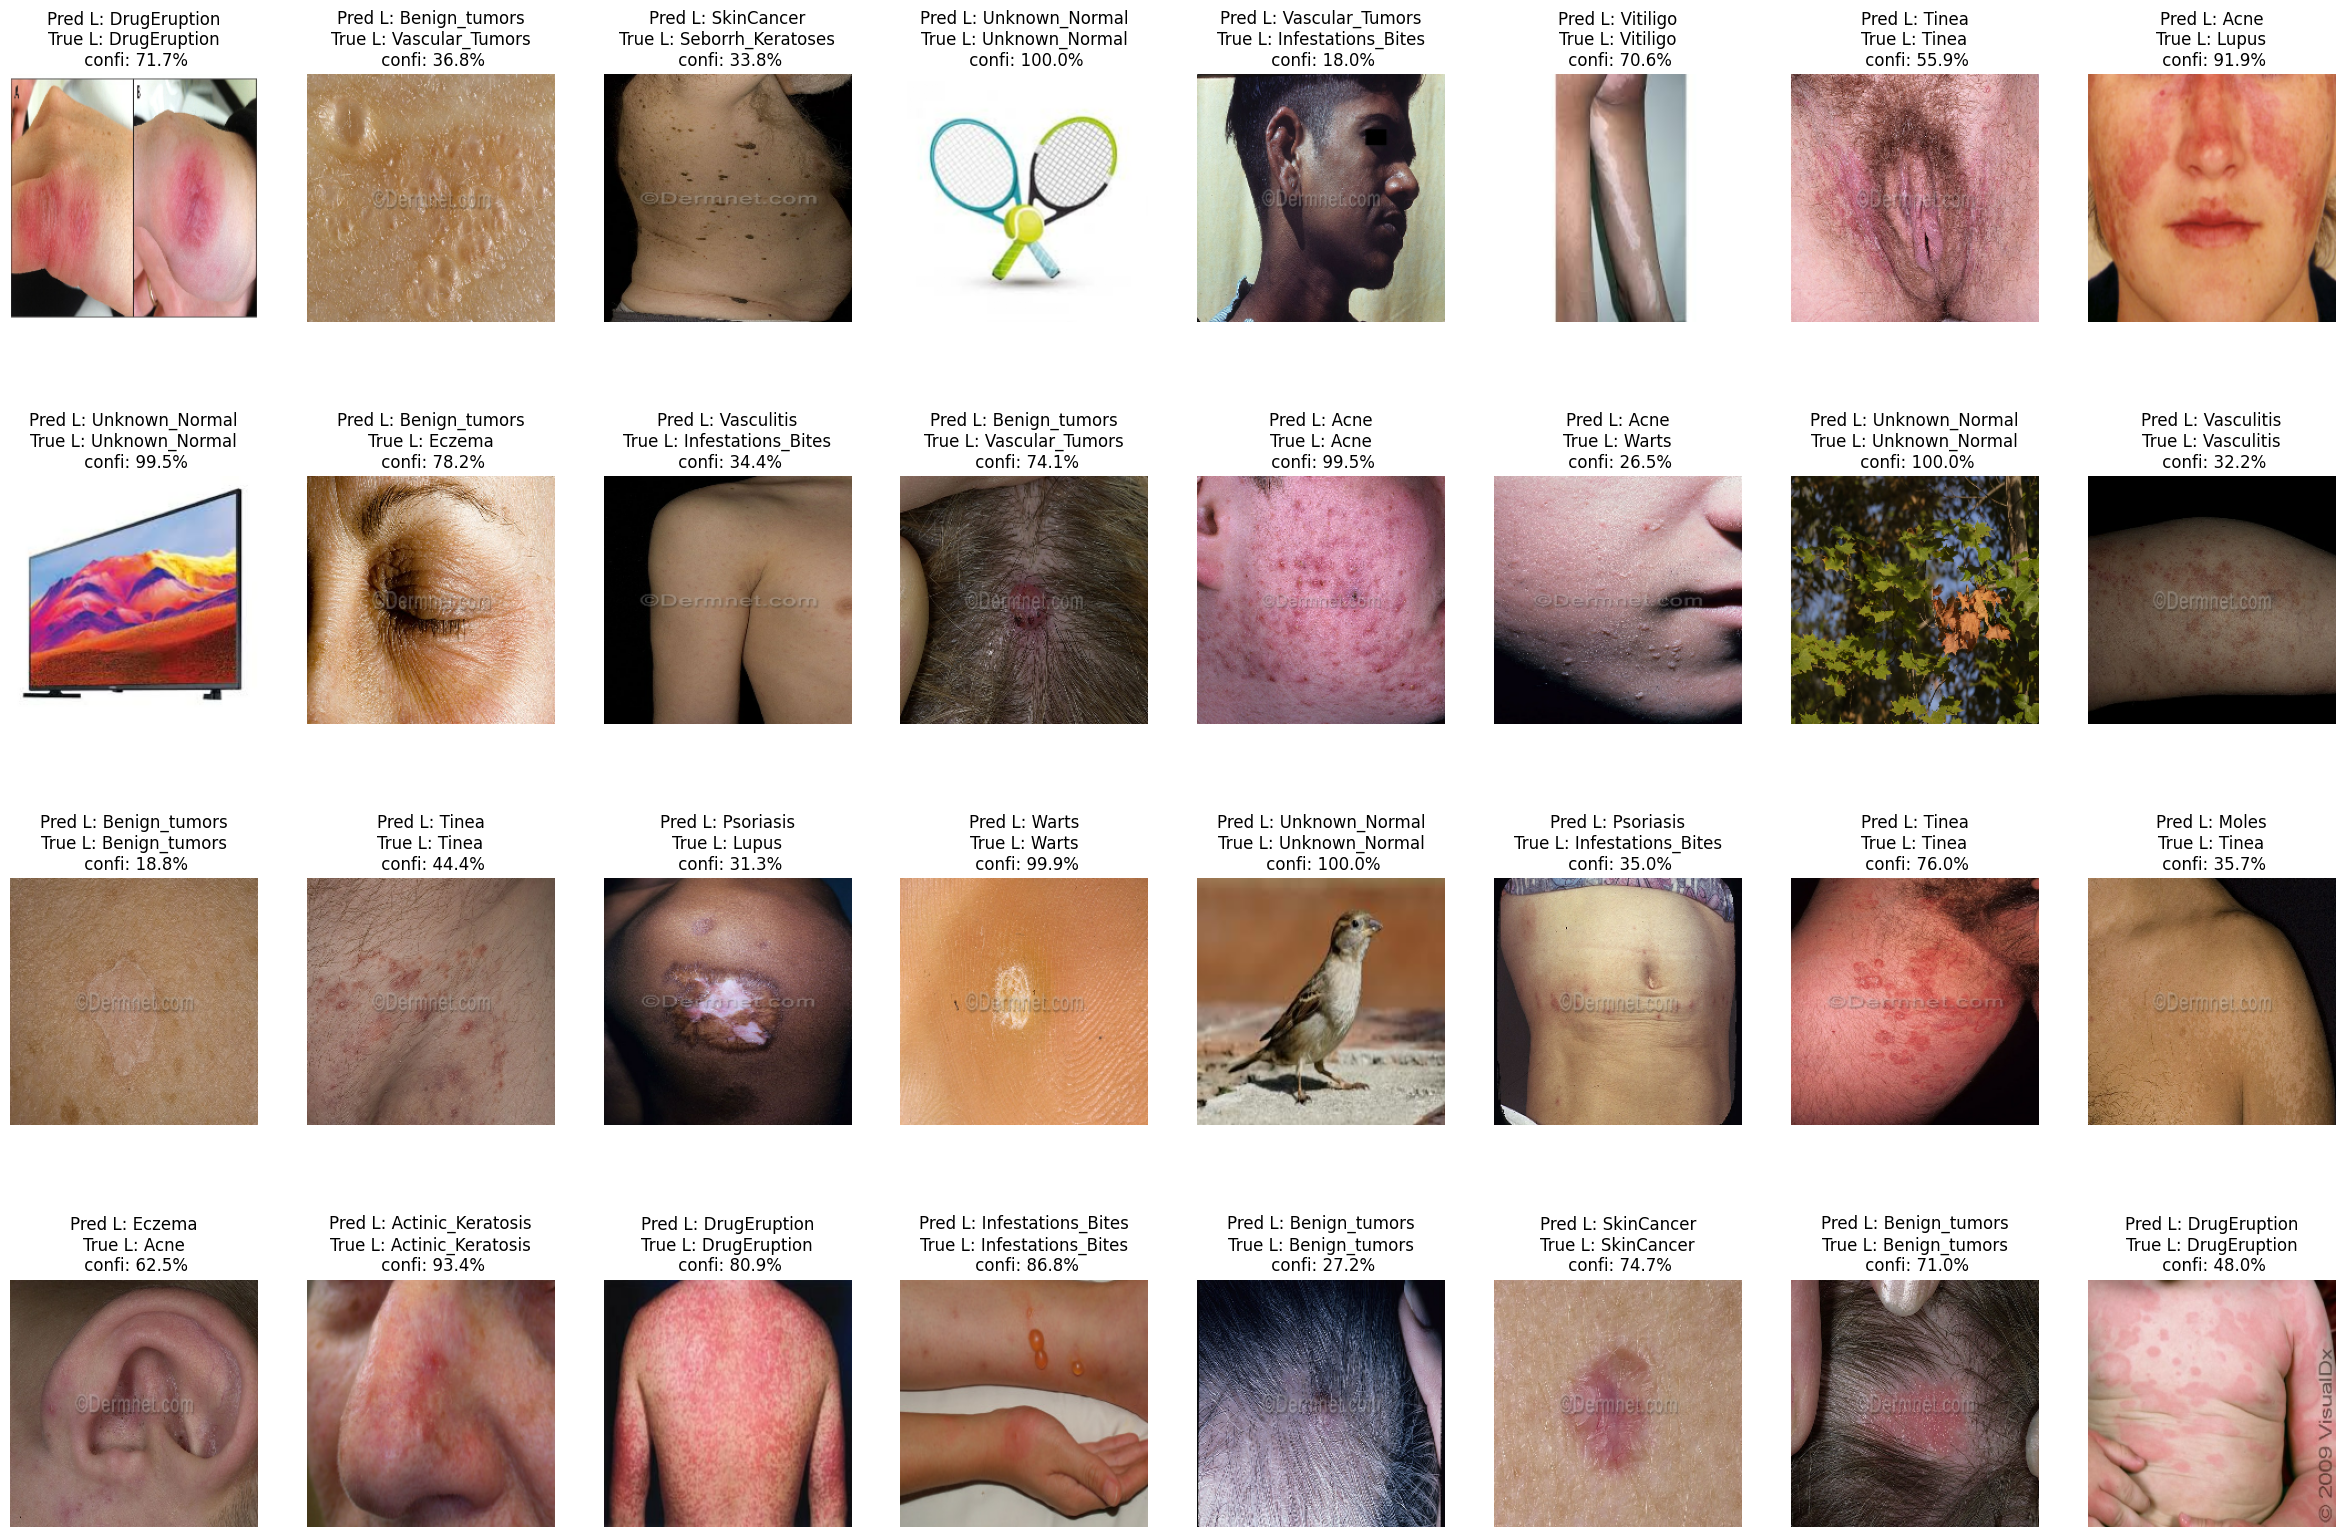

In [25]:
plt.figure(figsize=(30, 20))
for images, labels in test_ds.take(1):
    prediction = model.predict(images)
    for i in range(32):
        pred_index = np.argmax(prediction[i])
        pred_label = class_names[pred_index]
        true_index = np.argmax(labels[i])
        true_label = class_names[true_index]
        confidence = np.max(prediction[i])*100

        plt.subplot(4, 8, i+1)
        plt.imshow(images[i])
        plt.title(f'Pred L: {pred_label}\nTrue L: {true_label}\n confi: {confidence:.1f}%')
        plt.axis('off')
plt.show()